In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

# -----------------------------
# 1) 물리 파라미터
# -----------------------------
k0 = 6.0          # 자유공간 파수 느낌의 상수
delta_n = 0.4     # 굴절률 변화량
sigma = 0.18      # 굴절률 bump 폭

# -----------------------------
# 2) 굴절률 분포 n(x,y)
# -----------------------------
def n_xy(x, y):
    return 1.0 + delta_n * torch.exp(-((x - 0.5)**2 + (y - 0.5)**2) / (sigma**2))

# -----------------------------
# 3) 정답 함수 u_true(x,y)
# -----------------------------
def u_true_fn(x, y):
    return torch.sin(np.pi * x) * torch.sin(np.pi * y)

# -----------------------------
# 4) 소스항 f(x,y)
#    PDE: u_xx + u_yy + k0^2 n^2 u = f
# -----------------------------
def f_xy(x, y):
    u = u_true_fn(x, y)
    lap_u = -2 * (np.pi**2) * u
    n = n_xy(x, y)
    return lap_u + (k0**2) * (n**2) * u

# -----------------------------
# 5) PINN 모델
# -----------------------------
class PINN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        return self.net(inp)

model = PINN2D()

# -----------------------------
# 6) collocation points (내부 점)
# -----------------------------
N_f = 2500
x_f = torch.rand((N_f, 1), requires_grad=True)
y_f = torch.rand((N_f, 1), requires_grad=True)

# -----------------------------
# 7) boundary points (경계 조건)
#    u = 0 on boundary
# -----------------------------
N_b = 400

# y=0, y=1
x_b1 = torch.rand((N_b, 1), requires_grad=True)
y_b1 = torch.zeros((N_b, 1), requires_grad=True)

x_b2 = torch.rand((N_b, 1), requires_grad=True)
y_b2 = torch.ones((N_b, 1), requires_grad=True)

# x=0, x=1
x_b3 = torch.zeros((N_b, 1), requires_grad=True)
y_b3 = torch.rand((N_b, 1), requires_grad=True)

x_b4 = torch.ones((N_b, 1), requires_grad=True)
y_b4 = torch.rand((N_b, 1), requires_grad=True)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# -----------------------------
# 8) 학습
# -----------------------------
for epoch in range(3000):
    u_f = model(x_f, y_f)

    # 1차 미분
    u_x = torch.autograd.grad(
        u_f, x_f, torch.ones_like(u_f), create_graph=True
    )[0]
    u_y = torch.autograd.grad(
        u_f, y_f, torch.ones_like(u_f), create_graph=True
    )[0]

    # 2차 미분
    u_xx = torch.autograd.grad(
        u_x, x_f, torch.ones_like(u_x), create_graph=True
    )[0]
    u_yy = torch.autograd.grad(
        u_y, y_f, torch.ones_like(u_y), create_graph=True
    )[0]

    n_f = n_xy(x_f, y_f)
    f_f = f_xy(x_f, y_f)

    # PDE residual
    residual = u_xx + u_yy + (k0**2) * (n_f**2) * u_f - f_f
    loss_pde = torch.mean(residual**2)

    # Boundary loss
    u_b1 = model(x_b1, y_b1)
    u_b2 = model(x_b2, y_b2)
    u_b3 = model(x_b3, y_b3)
    u_b4 = model(x_b4, y_b4)

    loss_bc = (
        torch.mean(u_b1**2) +
        torch.mean(u_b2**2) +
        torch.mean(u_b3**2) +
        torch.mean(u_b4**2)
    )

    loss = loss_pde + 10.0 * loss_bc

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 300 == 0:
        print(
            f"epoch={epoch}, total={loss.item():.6e}, "
            f"pde={loss_pde.item():.6e}, bc={loss_bc.item():.6e}"
        )

epoch=0, total=1.335916e+02, pde=1.331779e+02, bc=4.137109e-02
epoch=300, total=2.093428e+00, pde=1.507492e+00, bc=5.859355e-02
epoch=600, total=1.525771e+00, pde=1.150570e+00, bc=3.752011e-02
epoch=900, total=4.118052e+00, pde=3.923433e+00, bc=1.946194e-02
epoch=1200, total=5.965127e-01, pde=4.041058e-01, bc=1.924069e-02
epoch=1500, total=5.074829e-01, pde=3.452003e-01, bc=1.622826e-02
epoch=1800, total=4.288808e-01, pde=2.929033e-01, bc=1.359775e-02
epoch=2100, total=2.280532e-01, pde=1.675602e-01, bc=6.049293e-03
epoch=2400, total=1.810574e-01, pde=1.330488e-01, bc=4.800855e-03
epoch=2700, total=1.534589e-01, pde=1.147911e-01, bc=3.866778e-03


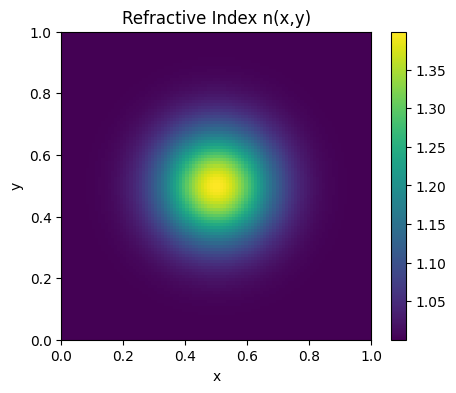

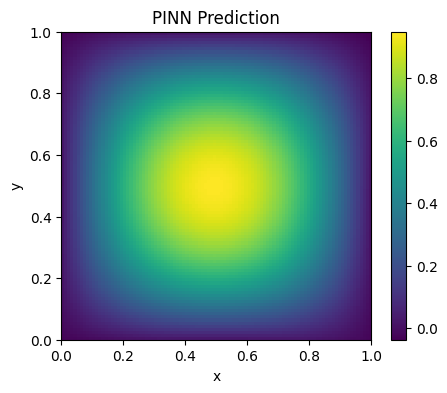

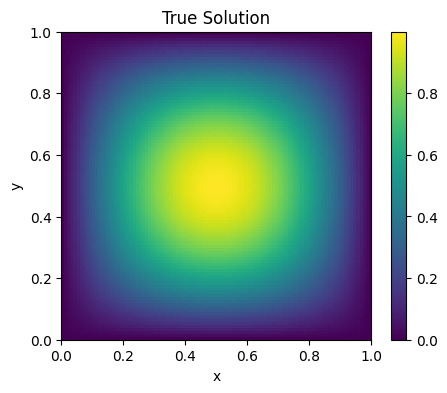

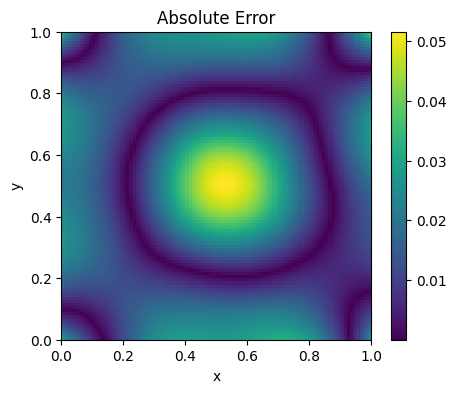

Mean absolute error = 0.015471272
Max absolute error  = 0.05157435


In [2]:
# 테스트 그리드
n_plot = 100
xv = np.linspace(0, 1, n_plot)
yv = np.linspace(0, 1, n_plot)
X, Y = np.meshgrid(xv, yv)

x_test = torch.tensor(X.reshape(-1, 1), dtype=torch.float32)
y_test = torch.tensor(Y.reshape(-1, 1), dtype=torch.float32)

with torch.no_grad():
    U_pred = model(x_test, y_test).cpu().numpy().reshape(n_plot, n_plot)
    N_map = n_xy(x_test, y_test).cpu().numpy().reshape(n_plot, n_plot)
    U_true = u_true_fn(x_test, y_test).cpu().numpy().reshape(n_plot, n_plot)

U_err = np.abs(U_pred - U_true)

plt.figure(figsize=(5,4))
plt.imshow(N_map, extent=[0,1,0,1], origin='lower', aspect='auto')
plt.colorbar()
plt.title("Refractive Index n(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.figure(figsize=(5,4))
plt.imshow(U_pred, extent=[0,1,0,1], origin='lower', aspect='auto')
plt.colorbar()
plt.title("PINN Prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.figure(figsize=(5,4))
plt.imshow(U_true, extent=[0,1,0,1], origin='lower', aspect='auto')
plt.colorbar()
plt.title("True Solution")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.figure(figsize=(5,4))
plt.imshow(U_err, extent=[0,1,0,1], origin='lower', aspect='auto')
plt.colorbar()
plt.title("Absolute Error")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

print("Mean absolute error =", U_err.mean())
print("Max absolute error  =", U_err.max())